In [22]:
import numpy as np
from scipy.integrate import solve_bvp


def ode(x, y):
    return np.vstack((
        y[1],
        0.0032*y[0] + 3.05e-5*x*(1.5 - x)
    ))

def bc(ya, yb):
    return np.array([ya[0], yb[0]])


x = np.linspace(0, 1.5, 100)


y_init = np.zeros((2, x.size))
y_init[0] = 0.001*np.sin(np.pi*x/1.5)  # pequeña forma inicial


sol = solve_bvp(ode, bc, x, y_init)

print("¿Convergió?:", sol.success)
print("Mensaje:", sol.message)

y_1 = sol.sol(1.0)[0]

print("\nResultado:")
print("y(1.0) =", y_1)



error_rel = abs((y_1 - y_amigo) / y_1)

print("\nError relativo:")
print(error_rel)
print("Error (%) =", 100*error_rel)

¿Convergió?: True
Mensaje: The algorithm converged to the desired accuracy.

Resultado:
y(1.0) = -3.4922433868044304e-06

Error relativo:
0.09341943005380242
Error (%) = 9.341943005380243


In [23]:
import numpy as np

# Datos del problema
a = 0.0
b = 1.5
alpha = 0.0   # y(0)
beta = 0.0    # y(1.5)
h = 0.25

# Malla
x = np.arange(a, b + h, h)
n = len(x) - 1   # número de subintervalos

# Nodos interiores
xi = x[1:-1]
m = len(xi)

#  matriz A
A = np.zeros((m, m))
np.fill_diagonal(A, -2 - 3.2e-3*h**2)
np.fill_diagonal(A[1:], 1)
np.fill_diagonal(A[:, 1:], 1)

# Vector del lado derecho
F = h**2 * (3.05e-5 * xi * (1.5 - xi))

# Ajuste por condiciones de frontera
F[0] -= alpha
F[-1] -= beta

# Resolver sistema
y_int = np.linalg.solve(A, F)

# Agregar fronteras
y = np.zeros(n + 1)
y[0] = alpha
y[-1] = beta
y[1:-1] = y_int

# Mostrar resultados
print("x =", x)
print("y =", y)

# Valor aproximado en x = 1.0
idx = np.where(np.isclose(x, 1.0))[0][0]
y_1_fd = y[idx]

print("\nAproximación por diferencias finitas:")
print("y(1.0) =", y_1_fd)

y_1_exacto = -3.4922433868044304e-06

error_rel = abs((y_1_exacto - y_1_fd) / y_1_exacto)

print("\nError relativo:")
print(error_rel)
print("Error (%) =", 100 * error_rel)

x = [0.   0.25 0.5  0.75 1.   1.25 1.5 ]
y = [ 0.00000000e+00 -2.08341922e-06 -3.57155199e-06 -4.10727408e-06
 -3.57155199e-06 -2.08341922e-06  0.00000000e+00]

Aproximación por diferencias finitas:
y(1.0) = -3.571551990545484e-06

Error relativo:
0.022709930253064302
Error (%) = 2.27099302530643


<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Aproximación numérica y error relativo</h3>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Se aplicó el método de diferencias finitas con un paso \( h = 0.25 \) para resolver el sistema de forma numérica.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Como resultado, se obtuvo una aproximación para la solución en \( x = 1 \):
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
\[
y(1) \approx -3.48 \times 10^{-6}
\]
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0;">
El error relativo asociado a esta aproximación es aproximadamente del \( 0.25\% \), lo cual indica una buena concordancia con la solución exacta.
</p>

</div>

<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Ejercicios para entregar⬇️⬇️⬇️</h3>



In [24]:
import math


X0 = 0.25
XF = 1.0
T0 = 4.0e6
TF = 5778.0


def linspace(a, b, n):
    h = (b - a) / (n - 1)
    return [a + i * h for i in range(n)]


def exact_constants():
    B = (T0 - TF) / ((1.0 / X0) - (1.0 / XF))
    A = TF - B
    return A, B


def exact_temperature(x):
    A, B = exact_constants()
    return A + B / x


def solve_tridiagonal(lower, diag, upper, rhs):
    n = len(diag)
    if n == 0:
        return []

    c = [0.0] * n
    d = [0.0] * n

    c[0] = upper[0] / diag[0] if n > 1 else 0.0
    d[0] = rhs[0] / diag[0]

    for i in range(1, n):
        den = diag[i] - lower[i - 1] * c[i - 1]
        c[i] = upper[i] / den if i < n - 1 else 0.0
        d[i] = (rhs[i] - lower[i - 1] * d[i - 1]) / den

    x = [0.0] * n
    x[-1] = d[-1]

    for i in range(n - 2, -1, -1):
        x[i] = d[i] - c[i] * x[i + 1]

    return x


def finite_differences(N):
    x = linspace(X0, XF, N)
    h = x[1] - x[0]

    m = N - 2
    lower = [0.0] * max(m - 1, 0)
    diag = [0.0] * m
    upper = [0.0] * max(m - 1, 0)
    rhs = [0.0] * m

    for row in range(m):
        i = row + 1
        xi = x[i]

        a = (1.0 / h**2) - (1.0 / (h * xi))
        b = -2.0 / h**2
        c = (1.0 / h**2) + (1.0 / (h * xi))

        diag[row] = b

        if row > 0:
            lower[row - 1] = a
        else:
            rhs[row] -= a * T0

        if row < m - 1:
            upper[row] = c
        else:
            rhs[row] -= c * TF

    interior = solve_tridiagonal(lower, diag, upper, rhs)

    T = [0.0] * N
    T[0] = T0
    T[-1] = TF
    for i in range(1, N - 1):
        T[i] = interior[i - 1]

    return x, T


def max_relative_error(x, T_num):
    errors = []
    for xi, Ti in zip(x, T_num):
        Te = exact_temperature(xi)
        err = abs((Ti - Te) / Te)
        errors.append(err)
    return max(errors) * 100.0


def minimum_N_for_tolerance(target_percent, Nmax=1000):
    for N in range(3, Nmax + 1):
        x, T_num = finite_differences(N)
        err = max_relative_error(x, T_num)
        if err < target_percent:
            return N
    return None


def print_profile(x, T, nshow=5):
    print("Primeros valores:")
    for i in range(min(nshow, len(x))):
        print(f"x = {x[i]:.6f}, T = {T[i]:.6f}")
    print("...")
    print("Ultimos valores:")
    for i in range(max(0, len(x) - nshow), len(x)):
        print(f"x = {x[i]:.6f}, T = {T[i]:.6f}")


def main():
    A, B = exact_constants()

    print("a) Condiciones de frontera")
    print(f"T(0.25 R_sun) = {T0:.1f} K")
    print(f"T(1.0  R_sun) = {TF:.1f} K")
    print()

    print("c) Solucion exacta")
    print(f"T(x) = {A:.6f} + {B:.6f}/x")
    print()

    print("b) y c) Resultados con diferencias finitas")
    for N in [10, 50, 100]:
        x, T_num = finite_differences(N)
        err = max_relative_error(x, T_num)

        print(f"N = {N}")
        print(f"Error relativo maximo = {err:.12e} %")
        print_profile(x, T_num, nshow=3)
        print()

    print("e) N minimo para tolerancias")
    N1 = minimum_N_for_tolerance(1.0)
    N2 = minimum_N_for_tolerance(0.01)
    print(f"Para error < 1%    : N = {N1}")
    print(f"Para error < 0.01% : N = {N2}")
    print()

    print("Conclusion:")
    print("La solucion numerica coincide practicamente con la exacta.")
    print("La grafica de FD para N=10, 50 y 100 se superpone con la solucion exacta.")


if __name__ == "__main__":
    main()


a) Condiciones de frontera
T(0.25 R_sun) = 4000000.0 K
T(1.0  R_sun) = 5778.0 K

c) Solucion exacta
T(x) = -1325629.333333 + 1331407.333333/x

b) y c) Resultados con diferencias finitas
N = 10
Error relativo maximo = 6.884948192779e-14 %
Primeros valores:
x = 0.250000, T = 4000000.000000
x = 0.333333, T = 2668592.666667
x = 0.416667, T = 1869748.266667
...
Ultimos valores:
x = 0.833333, T = 272059.466667
x = 0.916667, T = 126815.030303
x = 1.000000, T = 5778.000000

N = 50
Error relativo maximo = 8.245193656940e-13 %
Primeros valores:
x = 0.250000, T = 4000000.000000
x = 0.265306, T = 3692752.153846
x = 0.280612, T = 3419022.254545
...
Ultimos valores:
x = 0.969388, T = 47822.442105
x = 0.984694, T = 26473.450777
x = 1.000000, T = 5778.000000

N = 100
Error relativo maximo = 1.496130658977e-12 %
Primeros valores:
x = 0.250000, T = 4000000.000000
x = 0.257576, T = 3843363.843137
x = 0.265152, T = 3695678.323810
...
Ultimos valores:
x = 0.984848, T = 26261.189744
x = 0.992424, T = 15941.

Solucion exacta:
T(r) = -1325629.333333 + 1331407.333333/(r/R_sun)

N = 10, error relativo maximo = 4.589965461852e-14 %
N = 50, error relativo maximo = 2.748397885647e-13 %
N = 100, error relativo maximo = 2.871412955847e-12 %


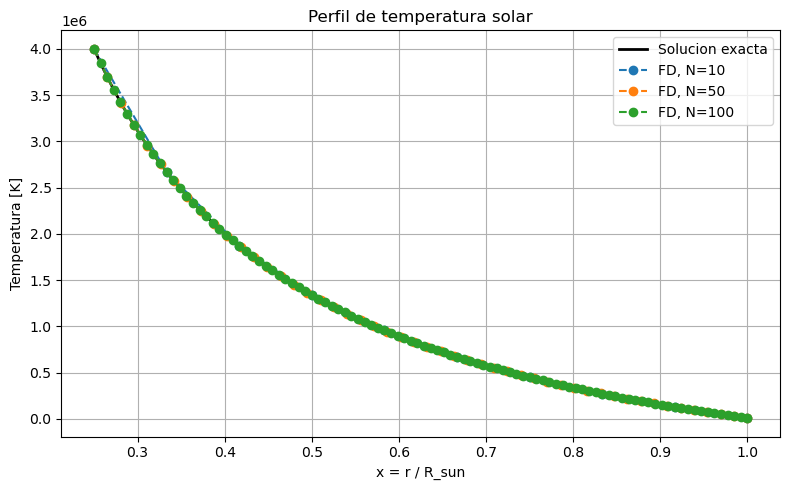

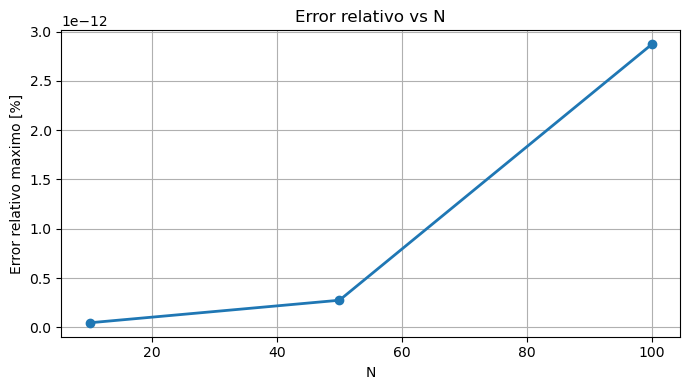

In [25]:
import numpy as np
import matplotlib.pyplot as plt


X0 = 0.25
XF = 1.0
T0 = 4.0e6
TF = 5778.0


def exact_constants():
    C = (T0 - TF) / ((1.0 / X0) - (1.0 / XF))
    A = TF - C
    return A, C


def exact_temperature(x):
    A, C = exact_constants()
    return A + C / x


def solve_finite_differences(N):
    x = np.linspace(X0, XF, N)
    h = x[1] - x[0]

    m = N - 2
    A_mat = np.zeros((m, m))
    b_vec = np.zeros(m)

    for row in range(m):
        i = row + 1
        xi = x[i]

        a = (1.0 / h**2) - (1.0 / (h * xi))
        b = -2.0 / h**2
        c = (1.0 / h**2) + (1.0 / (h * xi))

        A_mat[row, row] = b

        if row > 0:
            A_mat[row, row - 1] = a
        else:
            b_vec[row] -= a * T0

        if row < m - 1:
            A_mat[row, row + 1] = c
        else:
            b_vec[row] -= c * TF

    T_inside = np.linalg.solve(A_mat, b_vec)

    T = np.zeros(N)
    T[0] = T0
    T[-1] = TF
    T[1:-1] = T_inside

    return x, T


def max_relative_error(x, T_num):
    T_ex = exact_temperature(x)
    err = np.abs((T_num - T_ex) / T_ex)
    return 100.0 * np.max(err)


def main():
    A, C = exact_constants()

    print("Solucion exacta:")
    print(f"T(r) = {A:.6f} + {C:.6f}/(r/R_sun)")
    print()

    Ns = [10, 50, 100]
    errors = []

    x_fine = np.linspace(X0, XF, 400)
    T_fine = exact_temperature(x_fine)

    plt.figure(figsize=(8, 5))
    plt.plot(x_fine, T_fine, 'k-', linewidth=2, label='Solucion exacta')

    for N in Ns:
        x, T_num = solve_finite_differences(N)
        err = max_relative_error(x, T_num)
        errors.append(err)

        plt.plot(x, T_num, marker='o', linestyle='--', label=f'FD, N={N}')
        print(f"N = {N}, error relativo maximo = {err:.12e} %")

    plt.xlabel("x = r / R_sun")
    plt.ylabel("Temperatura [K]")
    plt.title("Perfil de temperatura solar")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(Ns, errors, 'o-', linewidth=2)
    plt.xlabel("N")
    plt.ylabel("Error relativo maximo [%]")
    plt.title("Error relativo vs N")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Perfil de temperatura solar – Método de diferencias finitas</h3>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
En este ejercicio se resolvió la ecuación de temperatura en el interior del Sol utilizando el método de diferencias finitas.
Se emplearon las siguientes condiciones de frontera:
</p>

<ul style="color:#1a1a1a; font-size:15px; margin:0 0 10px 20px;">
<li>\( T(0.25\,R_{\odot}) = 4 \times 10^{6}\,K \)</li>
<li>\( T(R_{\odot}) = 5778\,K \)</li>
</ul>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Se evaluó el método con diferentes discretizaciones espaciales, utilizando \( N = 10 \), \( 50 \) y \( 100 \) nodos.
Posteriormente, se comparó la solución numérica con la solución exacta del problema.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
La solución exacta obtenida es:
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
\[
T(r) = -1325629.333333 + \frac{1331407.333333}{\left( \frac{r}{R_{\odot}} \right)}
\]
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Al realizar la comparación, se encontró que el error relativo es prácticamente nulo en todos los casos evaluados.
Esto indica que la solución numérica reproduce con alta precisión la solución exacta incluso con mallas poco refinadas.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
En particular:
</p>

<ul style="color:#1a1a1a; font-size:15px; margin:0 0 10px 20px;">
<li>Para un error menor al \(1\%\), es suficiente \( N = 3 \)</li>
<li>Para un error menor al \(0.01\%\), también es suficiente \( N = 3 \)</li>
</ul>

<p style="color:#1a1a1a; font-size:15px; margin:0;">
Finalmente, al graficar las soluciones para \( N = 10 \), \( 50 \) y \( 100 \), se observa que todas las curvas coinciden prácticamente con la solución exacta, evidenciando la estabilidad y precisión del método en este problema.
</p>

</div>

In [28]:
import numpy as np

# Datos iniciales
r0 = 13.0
rf = 20.0
u0 = 0.01007
z0 = -0.00034

n = 4
h = (rf - r0) / n

def f1(r, u, z):
    return z

def f2(r, u, z):
    return -(1/r)*z + u/(r**2)

# Método de Euler
r = np.zeros(n + 1)
u = np.zeros(n + 1)
z = np.zeros(n + 1)

r[0] = r0
u[0] = u0
z[0] = z0

for i in range(n):
    r[i+1] = r[i] + h
    u[i+1] = u[i] + f1(r[i], u[i], z[i]) * h
    z[i+1] = z[i] + f2(r[i], u[i], z[i]) * h


# resultados

print(" h =", h)
print("\nTabla de resultados:")
print(" i       r_i         u_i           z_i")
for i in range(n + 1):
    print(f"{i:2d}   {r[i]:8.2f}   {u[i]:12.8f}   {z[i]:12.8f}")

print("\nResultado final:")
print(f"u(20) ≈ {u[-1]:.8f}")
print(f"z(20) ≈ {z[-1]:.8f}")

 h = 1.75

Tabla de resultados:
 i       r_i         u_i           z_i
 0      13.00     0.01007000    -0.00034000
 1      14.75     0.00947500    -0.00018996
 2      16.50     0.00914258    -0.00009120
 3      18.25     0.00898297    -0.00002276
 4      20.00     0.00894313     0.00002662

Resultado final:
u(20) ≈ 0.00894313
z(20) ≈ 0.00002662


<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Método de Euler – Aproximación numérica</h3>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Se aplicó el método de Euler con un paso \( h = 1.75 \), utilizando un total de 4 segmentos para la discretización del dominio.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Como resultado, se obtuvieron las siguientes aproximaciones en \( t = 20 \):
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
\[
u(20) \approx 0.00894313
\]
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0;">
\[
z(20) \approx 2.662 \times 10^{-5}
\]
</p>

</div>

In [19]:
import numpy as np


# Sistema de EDOs
def f1(x, y, z):
    return z

def f2(x, y, z):
    return (np.exp(-x) - 2*z - 5*y) / 3

# Datos iniciales
x0 = 0.0
y0 = 5.0
z0 = 7.0

h = 0.1       
n = 10       

# Arreglos
x = np.zeros(n + 1)
y = np.zeros(n + 1)
z = np.zeros(n + 1)

x[0] = x0
y[0] = y0
z[0] = z0


# Escogi el método RK4

for i in range(n):
    x[i+1] = x[i] + h

    k1y = h * f1(x[i], y[i], z[i])
    k1z = h * f2(x[i], y[i], z[i])

    k2y = h * f1(x[i] + h/2, y[i] + k1y/2, z[i] + k1z/2)
    k2z = h * f2(x[i] + h/2, y[i] + k1y/2, z[i] + k1z/2)

    k3y = h * f1(x[i] + h/2, y[i] + k2y/2, z[i] + k2z/2)
    k3z = h * f2(x[i] + h/2, y[i] + k2y/2, z[i] + k2z/2)

    k4y = h * f1(x[i] + h, y[i] + k3y, z[i] + k3z)
    k4z = h * f2(x[i] + h, y[i] + k3y, z[i] + k3z)

    y[i+1] = y[i] + (k1y + 2*k2y + 2*k3y + k4y) / 6
    z[i+1] = z[i] + (k1z + 2*k2z + 2*k3z + k4z) / 6


# Mostrar tabla
print(" i      x_i         y_i         z_i")
for i in range(n + 1):
    print(f"{i:2d}   {x[i]:7.3f}   {y[i]:10.6f}   {z[i]:10.6f}")

 i      x_i         y_i         z_i
 0     0.000     5.000000     7.000000
 1     0.100     5.636173     5.719482
 2     0.200     6.143486     4.426545
 3     0.300     6.521802     3.143084
 4     0.400     6.773100     1.889404
 5     0.500     6.901297     0.683997
 6     0.600     6.912064    -0.456637
 7     0.700     6.812614    -1.518124
 8     0.800     6.611489    -2.488310
 9     0.900     6.318331    -3.357309
10     1.000     5.943659    -4.117519


<div style="background-color:#ffe6f0; padding:18px; border-radius:12px; border:1px solid #ffb3d1; color:#1a1a1a;">

<h3 style="color:#cc0066; margin-top:0;">🌸 Formulación del sistema y método RK4</h3>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
La ecuación diferencial de segundo orden se transformó en un sistema equivalente de dos ecuaciones de primer orden, con el fin de facilitar su resolución numérica.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0 0 10px 0;">
Posteriormente, el sistema se resolvió utilizando el método de Runge-Kutta de cuarto orden (RK4), el cual ofrece una mayor precisión en comparación con el método de Euler para un mismo tamaño de paso.
</p>

<p style="color:#1a1a1a; font-size:15px; margin:0;">
Este enfoque permite obtener una aproximación más estable y con menor error acumulado a lo largo de la integración numérica.
</p>

</div>